# Optimising the Wind in Seismic Signals

## 0. Imports

In [ ]:

import yaml
from pathlib import Path
from obspy import UTCDateTime as UTC

import wind
import align
import process

config_path = ###

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
aws_path = config["aws_data_path"]


## 1. Gather Data

### 1.1 AWS Data

In [2]:
# Load Data
skiway = wind.read_data(path=aws_path, station_code='300060', id_code='55510926053')
WS = wind.wind_speed(skiway, year = 2022, month = 12, day = (25), hour = None, plot = False)

### 1.2 Seismic Data

In [3]:
CWA = align.seismic_data('AUSPASS', 'Z9', 'CWA81', "*", "*", UTC(2022, 12, 25, 0, 0,0), UTC(2023, 1, 1, 0, 0, 0), user1='Z9', password1='peach25')

File not found. Downloading data
Saved to: station_data_Z9_5stations_2022-12-25.mseed


## 2. Seismic preprocessing

### 2.1 Rotation Correction

In [4]:
CWA_rotated = align.rotate_stream(CWA, ['HHN'], ['HHE'], ['HHZ'], [-1.34])

Processing Z9.CWA81....


### 2.2 Amplitude Correction

In [5]:
CWA_amplitude_corrected = process.amplitude_correction(CWA_rotated[1], ['HHN'], ['HHE'], ['HHZ'], [100/113], [100/101], [100/10])

Processing Z9.CWA81....


### 2.3 Demean, Detrend

In [6]:
CWA_dd = align.demean_detrend(CWA_amplitude_corrected)

### 2.4 Taper

In [7]:
CWA_hann = align.apply_window(CWA_dd, max_length=300)

## 3. Montecarlo Test on Optimal Filter Frequencies to Maximise Similarity between SNR and Wind Speed

In [8]:
monte = wind.montecarlo_optimal_snr(wind_speed = WS, 
                            wave_dict = CWA_hann, 
                            freq_range = (10,15),
                            n_iterations = 1, 
                            NS_channel = ["HHN"],
                            EW_channel = ["HHE"],
                            Z_channel = ["HHZ"])

Processing Z9.CWA81....
Completed 1/1 iterations

Best frequency range for Z9.CWA81.: 12 - 13 Hz
Z R²: 0.1048
NS R²: 0.0569
EW R²: 0.0599
Average R²: 0.0739


## 4. Plot the Best Result from Part 3.

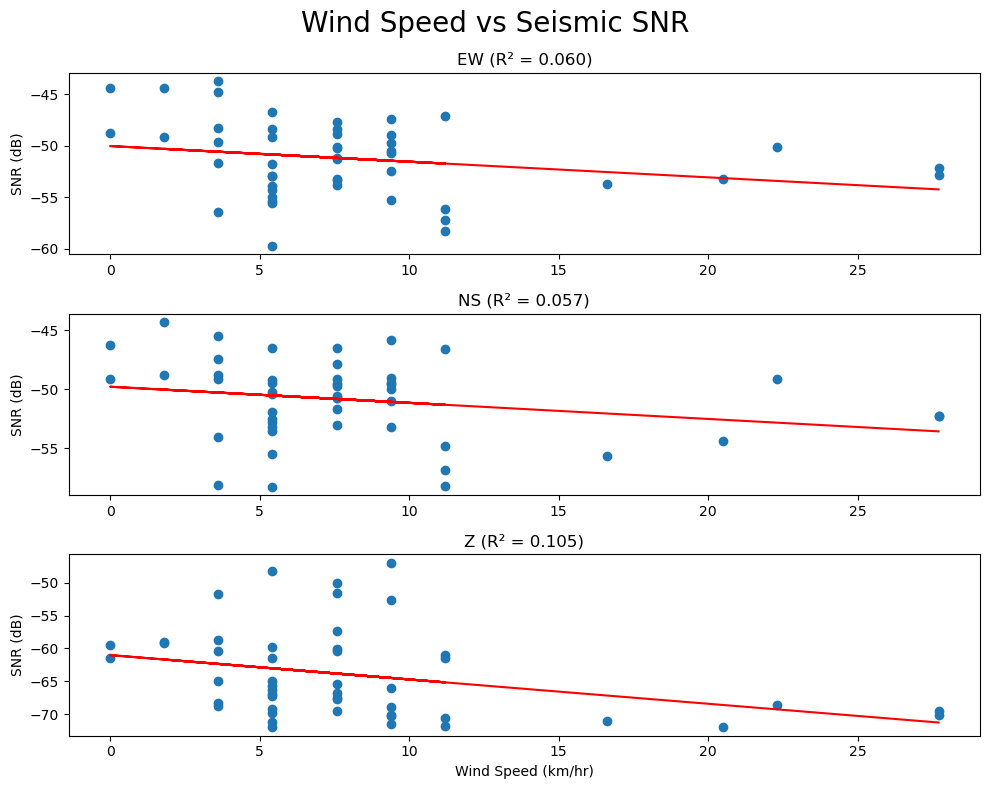

In [9]:
wind.plot_statistics(monte)